In [755]:
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 1. Functions

## 1.1 Read and process .scan files

In [756]:
import h5py

def read_scan(path_scan, verbose = False):
    """
    Read a 3D scan from a given path and return the data and metadata.
    Args:
        path_scan (str): Path to the .scan file.
        verbose (bool): If True, print additional information about the scan.
    Returns:
        tuple: A tuple containing the data and metadata from the scan.
    """
    
    file_scan = h5py.File(path_scan, "r") 
    data = file_scan['Data'][()]
    metadata = file_scan['acqMetaData']

    if verbose:
        print("\n------scan keys------")
        print(file_scan.keys())
        for key in file_scan.keys():
            print(f"{key}: {file_scan[key]} ")
        print("\ndata shape:", data.shape)
        print("\n-----aqui. metadata keys------")
        for key in metadata.keys():
            print(f"{key}  : {metadata[key]}")

    return data, metadata

def read_bps(path_bps, verbose = False):
    """
    Read a BPS file and return BrainToLab affine matrix.
    Args:
        path_bps (str): Path to the .bps file.
        verbose (bool): If True, print additional information about the BPS file.
    Returns:
        tuple: A tuple containing the BrainToLab affine matrix.
    """
    
    metadata_bps = h5py.File(path_bps, "r") 

    if verbose:
        print("------bps keys------")
        print(metadata_bps.keys())
        for key in metadata_bps.keys():
            print(f"{key}: {metadata_bps[key].shape} {metadata_bps[key].dtype}")
    return metadata_bps


In [757]:
def volume3D_from_scan_stack(scan_stack_data,*, probe_type = 'Linear', mean_frames = True, verbose = False):
    """
    Process a 3D scan data array and return a 3D data array suitable for visualization.
    Args:
        scan3D_data (np.ndarray): 5D array with shape (N_scan, frames, Z_vox, Y_vox, X_vox).
        probe_type (str): Type of probe used for the scan ('Linear' or other).
        verbose (bool): If True, print additional information about the processing.
    Returns:
        np.ndarray: A 3D array with shape (X_vox, Y_vox, Z_vox) suitable for visualization.
    """

    if scan_stack_data.ndim != 5:
        raise ValueError("Input scan3D_data must be a 5D array with shape (N_scan, frames, Z_vox, Y_vox, X_vox)")
    
    n_scan, nt, nz, ny, nx = scan_stack_data.shape

    if mean_frames and nt > 1:
        # If mean_frames is True, average over the time dimension
        print(scan_stack_data)
        scan_stack_data = np.mean(scan_stack_data, axis=1, keepdims=True)
        print(scan_stack_data)
    else:
        scan_stack_data = scan_stack_data[:,0,:,:,:]

    if probe_type == 'Linear':
        if ny != 1:
            raise ValueError("For linear probes, the Y dimension should be 1.")
        # For linear probes, we assume N_scan corresponds to different scan lines, and we want to
        # create a 3D volume where each scan line is a slice in the Y dimension.
        # Thus, we assume dy (distance between adjacent scan lines) is small
        # enough to consider it as a voxel in the Y dimension.

        stack_processed = scan_stack_data.squeeze().transpose([2, 0, 1])
    else:
        print(f"Probe type {probe_type} not recognized. Returning original data.")
        stack_processed = scan_stack_data

    if verbose:
        print("Processing scan stack data...")
        print("Original scan_stack_data shape:", scan_stack_data.shape)
        print("Processed scan_stack_data shape:", stack_processed.shape)
    
    return stack_processed

def image2D_from_scan(scan_data,*, probe_type = 'Linear', mean_frames = True, verbose = False):
    """
    Process a 2D scan data array and return a 2D data array suitable for visualization.
    Args:
        scan_data (np.ndarray): 4D array with shape (frames, Z_vox, Y_vox, X_vox).
        probe_type (str): Type of probe used for the scan ('Linear' or other).
        mean_frames (bool): If True, average over the time dimension.
        verbose (bool): If True, print additional information about the processing.
    Returns:
        np.ndarray: A 2D array with shape (X_vox, Y_vox=1, Z_vox) suitable for visualization.
    """

    if scan_data.ndim != 4:
        raise ValueError("Input scan_data must be a 4D array with shape (frames, Z_vox, Y_vox, X_vox)")
    
    nt, nz, ny, nx = scan_data.shape

    if mean_frames and nt > 1:
        # If mean_frames is True, average over the time dimension
        scan_data = np.mean(scan_data, axis=0, keepdims=False)
    else:
        scan_data = scan_data[0,:,:,:]

    if probe_type == 'Linear':
        if ny != 1:
            raise ValueError("For linear probes, the Y dimension should be 1.")
        
        scan_processed = scan_data.transpose([2, 1, 0])
    else:
        print(f"Probe type {probe_type} not recognized. Returning original data.")
        scan_processed = scan_data

    if verbose:
        print("Processing scan data...")
        print("Original scan_data shape:", scan_data.shape)
        print("Processed scan_data shape:", scan_processed.shape)
    
    return scan_processed

## 1.3. read bg_atlas functions

In [758]:
def get_pv_mesh_from_atlas(bg_atlas, regions_names):
    """
    Get a PyVista mesh from the BrainGlobe Atlas for a given structure name.
    Args:
        bg_atlas (BrainGlobeAtlas): The BrainGlobe Atlas object.
        structure_name (str or list/tuple/set): The name of the structure(s) to retrieve.
    Returns:
        pv_mesh (dict): A dictionary containing the PyVista mesh(es) for the specified structure(s).
    """
    pv_mesh = {}
    if not isinstance(regions_names, str):
        try:
            n_reg = len(regions_names)            
            for i, region_name in enumerate(regions_names):
                print(f"Processing region {i+1}/{n_reg}: {region_name}")
                print(f"Found structure: {bg_atlas.structures[region_name]['name']}")
                pv_mesh[region_name] = pv.read(bg_atlas.structures[region_name]['mesh_filename'])
        except KeyError as e:
            print(f"Error: {e}. Please check the structure names provided.")
            return None
        return pv_mesh
    else:
        print(f"Structure name: {bg_atlas.structures[regions_names]['name']}")
        pv_mesh[regions_names] = pv.read(bg_atlas.structures[regions_names]['mesh_filename'])
        return pv_mesh


In [759]:

import brainglobe_space as bg_space

def get_bgatlasToBrain(bg_atlas, *, whs_voxels = None, verbose = False, brain_mesh_dict = None):
    """
    Compute the transformation matrix from BrainGlobe Atlas to Brain-space (BPS Atlas).
    Args:
        bg_atlas (BrainGlobeAtlas): The BrainGlobe Atlas object.
        brain_mesh_dict (dict, optional): A dictionary of PyVista meshes for different brain regions.
        whs_voxels (dict, optional): A dictionary containing the WHS origin, bregma, and lambda voxels.
    Returns:
        np.ndarray: The transformation matrix from BrainGlobe Atlas to Brain-space (BPS Atlas).
        transformed_brain_mesh_dict (dict, optional): A dictionary of transformed PyVista meshes for different brain regions, if provided.
    """
    name = bg_atlas.metadata['name']
    if  name == "whs_sd_rat":
        # We need to apply a specific transformation to align the BrainGlobe atlas
        # with the WHS atlas space.
        print(f"WHS origin, bregma, and lambda coordinates available for `{name}`.")
        whs_voxels = {
        'origin' : np.array([244, 623, 248]),
        'bregma' : np.array([246, 653, 440]),
        'lambda' : np.array([244, 442, 434]),
        }
    elif whs_voxels is not None:
        # If whs_voxels is provided, we use it to align the atlas
        print("Using provided WHS voxels for alignment.")
        pass
    else:
        raise ValueError("No available information for this atlas. \n" \
        "To compute BrainGlobe to Brain-space, the WHS origin, bregma, and lambda voxels must be provided.")

    # Get the information to compute transformation matrix
    resolution = np.array(bg_atlas.metadata['resolution']) 
    bregma2lambda = np.linalg.norm((whs_voxels['lambda'] - whs_voxels['bregma']))
    normalize_bregma2sigma =  np.diag(np.concatenate(([1/bregma2lambda]*3, [1])))  # Add a 1 for homogeneous coordinates

    # Take to whs orientation RAS+
    target_space = bg_space.AnatomicalSpace("lpi") # New resolution to change the units from um to mm
    set_whs_orientation = bg_atlas.space.transformation_matrix_to(target_space)

    # Create the transformation matrix from BrainGlobe Atlas to whs Atlas
    resolution2Voxel =  np.diag(np.concatenate((1/resolution, [1])))  # Add a 1 for homogeneous coordinates
    set_whs_origin = np.eye(4)
    set_whs_origin[:3, 3] = -whs_voxels['origin']

    # Create the transformation matrix from BrainGlobe Atlas to BPS Atlas
    bgatlasToBrain =  normalize_bregma2sigma @ set_whs_origin @ set_whs_orientation @ resolution2Voxel 

    if verbose:
        print("WHS origin in voxel coordinates:", whs_voxels['origin'])
        print("Bregma in voxel coordinates:", whs_voxels['bregma'])
        print("Lambda in voxel coordinates:", whs_voxels['lambda'])
        print("bgatlasToBrain:\n", bgatlasToBrain)    

    if brain_mesh_dict is not None:
        # If a brain mesh dictionary is provided, we can transform it to the BPS Atlas space
        transformed_meshes = {}
        for region_name, mesh in brain_mesh_dict.items():
            trans_mesh = mesh.copy()  # Create a copy of the mesh to avoid modifying the original
            trans_mesh.transform(bgatlasToBrain, inplace=True)
            transformed_meshes[region_name] = trans_mesh
        
        return bgatlasToBrain, transformed_meshes

    return bgatlasToBrain

In [760]:
def get_qform_and_sform(scan_metadata, bps_metadata, bg_atlas, *,
              verbose = False, return_all = True):
    """
    Extract the qform (voxel -> scanner (transducer) coordinates transformation) 
    and the sform (voxel -> anatomical (bg_atlas) coordinates transformation)
    Args:
        scan_metadata (h5py.File): The metadata of the scan.    
        bps_metadata (h5py.File): The metadata of the BPS file.
        bg_atlastToBrain (np.ndarray): The BrainGlobe Atlas to Brain (scan-atlas space) transformation matrix (default is identity).
        verbose (bool): If True, print original data on metadata.
        return_all (bool): If True, return all affine matrices need for transformation between spaces.
    Returns:
        np.ndarray: The qform matrix (4x4) that transforms voxel coordinates to lab coordinates.
    """

    invert_z = np.diag([1, 1, -1, 1])  # Invert z-axis

    # Get the probeToLab, voxelsToProbe, and BrainToLab matrices from the scan metadata
    probeToLab = scan_metadata["probeToLab"][()]
    voxelsToProbe = scan_metadata["voxelsToProbe"][()]    

    # Get the BrainToLab affine matrix from the BPS metadata
    BrainToLab = bps_metadata['BrainToLab'][()]
    
    if probeToLab.ndim > 2 :
        # If probeToLab is a 3D array, we assume the first slice corresponds to the probe to lab transformation
        n_scans = probeToLab.shape[0]
        print("probeToLab shape:", probeToLab.shape, ", n_scans:", n_scans)
        probeToLab = probeToLab[1, :, :].squeeze()
    
    # Get the BrainGlobe Atlas to Brain (scan-atlas space) transformation matrix
    bg_atlasToBrain = get_bgatlasToBrain(bg_atlas, verbose = verbose)  # Get the transformation matrix from BrainGlobe Atlas to Brain-space (BPS Atlas)
    
    bg_atlasToLab = BrainToLab @ bg_atlasToBrain
    bg_atlasToProbe = np.linalg.inv(probeToLab) @ BrainToLab @ bg_atlasToBrain

    qform = invert_z @ voxelsToProbe
    sform = invert_z @ np.linalg.inv(bg_atlasToProbe) @ voxelsToProbe

    if verbose:
        print("\nBrainToLab: \n", BrainToLab)
        print("probeToLab: \n", probeToLab)
        print("voxelsToProbe: \n", voxelsToProbe)
        print("qform: \n", qform)
        print("sform: \n", sform)

    if return_all:
        trans_matrix = {
            'voxelsToProbe': voxelsToProbe,
            'probeToLab': probeToLab,
            'BrainToLab': BrainToLab,
            'bg_atlasToLab':  bg_atlasToLab,
            'bg_atlasToBrain':  bg_atlasToBrain,
            'bg_atlasToProbe':  invert_z @ bg_atlasToProbe,
            'qform': qform, # voxel -> scanner (probe) coordinates transformation
            'sform':  sform, # voxel -> anatomical (bg_atlas) coordinates transformation
        }
        # If return_all is True, return the qform matrix
        return trans_matrix

    return qform, sform


## 1.5. Plotting functions

In [761]:
def add_regions_mesh(pv_regions_dict, *,
                        plotter=None,
                        window_size= [800, 800],
                        notebook=True,
                        off_screen=False,
                        kwargs_dict=None, **kwargs):
    """
    Plot the PyVista mesh of a specified structure.
    Args:
        pv_regions_dict (dict): A dictionary of PyVista meshes for different brain regions.
        window_size (list, optional): Size of the plot window. Default is [800, 800].
        notebook (bool, optional): Whether to use notebook mode for the plotter. Default is True.
        off_screen (bool, optional): Whether to render the plot off-screen. Default is False.
        kwargs_dict (dict, optional): Additional keyword arguments for the mesh rendering.
    Returns:
        pv.Plotter: The PyVista plotter with the mesh added.
    """
    if plotter is None:
        plotter = pv.Plotter(notebook=notebook, window_size=window_size, 
                             off_screen=off_screen)
    default_kwargs = {
        'color': 'lightgrey',  # Default color for the mesh
        'opacity': 0.4,  # Default opacity for the mesh
    }

    if isinstance(pv_regions_dict, dict):
        for region in pv_regions_dict.keys():
            if region not in kwargs_dict.keys():
                kwargs = default_kwargs
            else:
                kwargs = kwargs_dict[region]
            kwargs['label'] = region
            plotter.add_mesh(pv_regions_dict[region], **kwargs)
    else:
        try: 
            for key, value in default_kwargs.items():
                if key not in kwargs:
                    kwargs[key] = value
            plotter.add_mesh(pv_regions_dict, **kwargs)
        except KeyError as e:
            
            raise ValueError(f"Error: {e}. pv_regions_dict should be a dictionary with brain region meshes or the mesh.")
        
    plotter.add_axes()
    return plotter


In [762]:
def add_transducer_mesh(TX_mesh, *,
                        plotter=None,
                        window_size=[800, 800],
                        notebook=True,
                        off_screen=False,
                        **kwargs):
    
    if plotter is None:
        plotter = pv.Plotter(notebook=notebook, window_size=window_size,
                             off_screen=off_screen)

    default_kwargs = {
        'scalars': 'Apodization',  # Assuming 'Apodization' is a scalar field in TX_mesh
        'cmap': 'cool',
        'clim': [0, 1],
        'opacity': 1.0,
        'show_edges': True,
        'show_scalar_bar': True,
        'scalar_bar_args': {
            'title': 'Apodization',
            "title_font_size": 16,
            "label_font_size": 12,
            'vertical': True,
            'position_x': 0.85,
            'position_y': 0.5,
            "height": 0.3,
        },
        'label' : "Transducer",  # label for the legend
        'color' : "purple", # color of the mesh
    }

    for key, value in default_kwargs.items():
        if key not in kwargs:
            kwargs[key] = value

    plotter.add_mesh(TX_mesh,   # Convert to mm for visualization
            **kwargs
        )
    plotter.add_axes()
    return plotter


In [763]:
def add_pressure_vol(pressure_vol,*,
                    plotter=None,
                    window_size=[800, 800],
                    notebook=True,
                    plot_focal_spot = True,
                    off_screen=False,
                    **kwargs):
    
    if plotter is None:
        plotter = pv.Plotter(notebook=notebook, window_size=window_size,
                             off_screen=off_screen)

    # 3) Add the pressure volume
    if plot_focal_spot:
        
        default_kwargs = {
            'opacity': 1,
            'name' : "PressureIso",
            'show_scalar_bar': False,
            'label': "Focal Spot",  # label for the legend
            'color' : "r", # color of the mesh
        }
        for key, value in default_kwargs.items():
            if key not in kwargs:
                kwargs[key] = value
                
        # pick a threshold, e.g. halfway to the max
        threshold = 0.7 * pressure_vol["Pressure"].max()
        iso_mesh = pressure_vol.contour([threshold], scalars="Pressure")  # Create isosurface at threshold# add that instead of (or in addition to) the volume
        plotter.add_mesh(iso_mesh, **kwargs)    

    else:
        n_contours = 10
        min_val = 0
        max_val = pressure_vol["Pressure"].max()
        levels = np.linspace(min_val, max_val, n_contours)
        iso_mesh = pressure_vol.contour(isosurfaces=levels, scalars="Pressure")  # Create isosurface at threshold
        default_kwargs = {
            'scalars': "Pressure",  # use the scalar to color surfaces
            'opacity': 'linear',
            'cmap' : "jet",
            'show_scalar_bar': True,
            'scalar_bar_args': {
                'title': 'Pressure (u.a.)',
                "title_font_size": 16,
                "label_font_size": 12,
                'vertical': True,
                'position_x': 0.85,
                'position_y': 0.2,
                "height": 0.3,
            },
            'label': "Pressure PII",  # label for the legend
            'color' : "r", # color of the mesh
        }
        for key, value in default_kwargs.items():
            if key not in kwargs:
                kwargs[key] = value

        plotter.add_mesh(iso_mesh, **kwargs)

    plotter.add_axes()
    return plotter

In [764]:
def create_doppler_mesh(processed_scan_3D, *, clip = None):
    """
    Create a 3D mesh from the processed scan data for Doppler visualization.
    Args:
        processed_scan_3D (np.ndarray): The processed 3D scan data.
        clip (tuple, optional): A tuple of two values (minclip_value, maxclip_value) to clip the Doppler data.
    Returns:
        pv.Plotter: The PyVista plotter with the Doppler mesh added.
    """

    # Convert processed_scan_3D to dB scale
    Doppler_dB = 20 * np.log10(np.abs(processed_scan_3D) / np.max(np.abs(processed_scan_3D)))
    if clip is not None:
        Doppler_dB = np.clip(Doppler_dB, clip[0], clip[1])

    # Create the 3D UniformGrid
    doppler3D_voxels = pv.ImageData(
        dimensions = Doppler_dB.shape
    )

    # Attach pressure data to the grid
    doppler3D_voxels.point_data["doppler"] = Doppler_dB.ravel(order="F")  # VERY important: Fortran order

    return doppler3D_voxels

def add_doppler_vol(doppler3D_vol,*, 
                    plotter = None,
                    notebook = True,
                    window_size = [700,700],
                    off_screen=False,
                    **kwargs):
    """
    Plot the ultrasound volume using PyVista.
    Args:
        doppler3D_vol (pv.ImageData): The ultrasound volume data.
        cmap (str): Colormap to use for the volume rendering.
        opacity (str or tuple): Opacity function for the volume rendering.
        clim (list): Color limits for the scalars.
    """
    if plotter is None:
        plotter = pv.Plotter(window_size=window_size, notebook=notebook,
                             off_screen=off_screen)
    
    default_kwargs = {
        'scalars': 'doppler',  # Assuming 'doppler' is a scalar field in doppler3D_vol
        'cmap': 'hot',
        'opacity': 'sigmoid',
        'mapper': 'smart',
        'show_scalar_bar': True,
        'scalar_bar_args': {
            'title': 'Doppler (dB)',
            "title_font_size": 16,
            "label_font_size": 12,
        },
    }
    for key, value in default_kwargs.items():
        if key not in kwargs:
            kwargs[key] = value
    
    vol = plotter.add_volume(doppler3D_vol, **kwargs)
    vol.prop.interpolation_type = 'linear'
    plotter.add_axes()
    return plotter

In [765]:
def create_2D_image_mesh(Bmode2D_dB, T) :
    """
    Compute a 2D image mesh from a B-mode ultrasound image and a transformation matrix.
    Args:
        Bmode2D_dB (np.ndarray): 2D array of B-mode ultrasound data in dB.
        T (np.ndarray): 4x4 transformation matrix to convert voxel coordinates to world coordinates.
    Returns:
        pv.StructuredGrid: A structured grid representing the 2D image in world coordinates.
    """
    H, W = Bmode2D_dB.shape

    # Create grid indices
    i_grid, j_grid = np.meshgrid(np.arange(W), np.arange(H))

    # Construct homogeneous voxel coordinates [j, 0, i, 1]
    points_voxel = np.stack([j_grid, np.zeros_like(j_grid), i_grid, np.ones_like(j_grid)], axis=-1)
    points_voxel_flat = points_voxel.reshape(-1, 4).T  # Shape (4, H*W)

    # Transform to world coordinates
    points_world_flat = T @ points_voxel_flat  # Shape (4, H*W)

    # Create structured grid
    xx = points_world_flat[0].reshape(H, W)
    yy = points_world_flat[1].reshape(H, W)
    zz = points_world_flat[2].reshape(H, W)
    grid = pv.StructuredGrid(xx, yy, zz)
    grid["doppler"] = Bmode2D_dB.ravel(order="F")  # Add scalar data # FORTRAN ORDER IMPORTANT
    return grid

def add_2D_image(image_grid,*, 
                plotter = None,
                notebook = True,
                window_size = [700,700],
                off_screen=False,
                **kwargs):
    """
    Plot the ultrasound volume using PyVista.
    Args:
        doppler3D_vol (pv.ImageData): The ultrasound volume data.
        cmap (str): Colormap to use for the volume rendering.
        opacity (str or tuple): Opacity function for the volume rendering.
        clim (list): Color limits for the scalars.
    """
    if plotter is None:
        plotter = pv.Plotter(window_size=window_size, notebook=notebook,
                                off_screen=off_screen)

    default_kwargs = {
        'show_edges':False,
        'cmap':'gray',
        'opacity':1.0,
        'name':'2D doppler',  # Name for the volume
        'show_scalar_bar':False,
        'show_scalar_bar': True,
        'scalar_bar_args': {
            'title': '2D Doppler (dB)',
            "title_font_size": 16,
            "label_font_size": 12,
            'vertical': True,
            'position_x': 0.1,
            'position_y': 0.2,
            "height": 0.3,
        },
        'label' : "2D Doppler",  # label for the legend	
    }
    for key, value in default_kwargs.items():
        if key not in kwargs:
            kwargs[key] = value

    vol=plotter.add_mesh(image_grid, **kwargs)
    plotter.add_axes()
    return plotter

# 2. Import and read data

In [766]:
gps_PATH = r"..\src\pysonogen\datatype\manual_gpsreg.bps"
file_scan_2D_PATH = r"..\src\pysonogen\datatype\2Dscan_with_motors_fus2D.source.scan"
file_scan_3D_PATH = r"..\src/pysonogen/datatype/3Dscan_200um_angio3D.source.scan"

# Let's take the 008 scan. It shouwld be placed at one sagittal plane on the left side of the brain

## 2.1 Import scan data

In [767]:
data_scan_3D, metadata_scan_3D = read_scan(file_scan_3D_PATH, verbose=True)
data_scan_2D, metadata_scan_2D = read_scan(file_scan_2D_PATH, verbose=True)


------scan keys------
<KeysViewHDF5 ['Data', 'acqMetaData', 'fileFormatVersion', 'fileID', 'scanMetaData', 'writingVersion']>
Data: <HDF5 dataset "Data": shape (43, 1, 112, 1, 128), type "<f8"> 
acqMetaData: <HDF5 group "/acqMetaData" (9 members)> 
fileFormatVersion: <HDF5 dataset "fileFormatVersion": shape (1, 1), type "<f8"> 
fileID: <HDF5 dataset "fileID": shape (1, 1), type "|O"> 
scanMetaData: <HDF5 group "/scanMetaData" (12 members)> 
writingVersion: <HDF5 dataset "writingVersion": shape (1, 1), type "<f8"> 

data shape: (43, 1, 112, 1, 128)

-----aqui. metadata keys------
acquisitionMode  : <HDF5 dataset "acquisitionMode": shape (1, 1), type "|O">
imgDim  : <HDF5 group "/acqMetaData/imgDim" (7 members)>
key7  : <HDF5 dataset "key7": shape (1, 1), type "|O">
probeToLab  : <HDF5 dataset "probeToLab": shape (43, 4, 4), type "<f8">
robotType  : <HDF5 dataset "robotType": shape (1, 1), type "|O">
time  : <HDF5 dataset "time": shape (43, 1), type "<f8">
timeOriginal  : <HDF5 dataset 

In [768]:
metadata_scan_3D

<HDF5 group "/acqMetaData" (9 members)>

In [769]:
processed_scan_3D = volume3D_from_scan_stack(data_scan_3D, probe_type='Linear', mean_frames=False, verbose=True)
processed_scan_2D = image2D_from_scan(data_scan_2D, probe_type='Linear', mean_frames=True, verbose=True)


Processing scan stack data...
Original scan_stack_data shape: (43, 112, 1, 128)
Processed scan_stack_data shape: (128, 43, 112)
Processing scan data...
Original scan_data shape: (112, 1, 128)
Processed scan_data shape: (128, 1, 112)


In [770]:
doppler3D_voxels = create_doppler_mesh(processed_scan_3D, clip=(-60, 0))

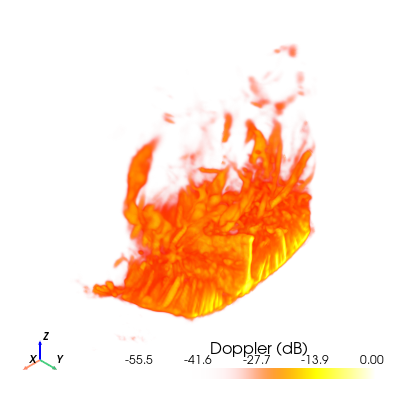

In [771]:
plotter_doppler = add_doppler_vol(doppler3D_voxels, notebook=True, window_size=[400, 400], cmap="hot", opacity="sigmoid")

plotter_doppler.show(jupyter_backend='static',title="Doppler Volume")

## 2.2. Import bps

In [772]:
bps_metadata = read_bps(gps_PATH, verbose=True)

------bps keys------
<KeysViewHDF5 ['BrainToLab', 'method', 'ref_name', 'score']>
BrainToLab: (4, 4) float64
method: (1, 1) object
ref_name: (1, 1) object
score: (1, 1) float64


## 2.3. Import atlas

In [773]:
from brainglobe_atlasapi import BrainGlobeAtlas

atlas_name = "whs_sd_rat_39um"
bg_atlas = BrainGlobeAtlas(atlas_name, check_latest=False)

Processing region 1/3: root
Found structure: Root
Processing region 2/3: M1
Found structure: Primary motor area
Processing region 3/3: S1-hl
Found structure: Primary somatosensory area, hindlimb representation
dict_keys(['root', 'M1', 'S1-hl'])


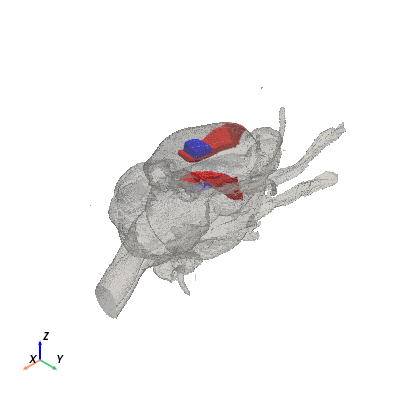

In [774]:
region_names = ("root", "M1", "S1-hl")

pv_brain_regions = get_pv_mesh_from_atlas(bg_atlas, region_names)
print(pv_brain_regions.keys())

plotter = add_regions_mesh(pv_brain_regions, notebook=True, window_size=[400, 400],
                         kwargs_dict={region_names[1]: {"color": "red"}, region_names[2]: {"color": "blue"}})

plotter.show(jupyter_backend='static')

## 3. Compute transformations to probe space

In [775]:
# We add additional transformations for visualization
rescale_m2mm = np.diag([1e3, 1e3, 1e3, 1])  # Rescale from meters to millimeters

In [776]:
affine_matrix_3D = get_qform_and_sform(metadata_scan_3D, bps_metadata, bg_atlas, verbose=True, return_all=True)
affine_matrix_2D = get_qform_and_sform(metadata_scan_2D, bps_metadata, bg_atlas, verbose=True, return_all=True)


probeToLab shape: (43, 4, 4) , n_scans: 43
WHS origin, bregma, and lambda coordinates available for `whs_sd_rat`.
WHS origin in voxel coordinates: [244 623 248]
Bregma in voxel coordinates: [246 653 440]
Lambda in voxel coordinates: [244 442 434]
bgatlasToBrain:
 [[ 0.00000000e+00  0.00000000e+00 -1.21466895e-04  1.26957198e+00]
 [-1.21466895e-04  0.00000000e+00  0.00000000e+00  1.89962077e+00]
 [ 0.00000000e+00 -1.21466895e-04  0.00000000e+00  1.25062315e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]

BrainToLab: 
 [[ 7.30249668e-03 -7.49453668e-04  1.94281872e-04 -1.53600034e-03]
 [ 1.75873895e-04  7.93594891e-03  1.08144651e-05  1.27103552e-02]
 [-1.76348435e-05  2.26471207e-04  7.70593407e-03 -1.11717150e-02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
probeToLab: 
 [[1.     0.     0.     0.    ]
 [0.     1.     0.     0.0052]
 [0.     0.     1.     0.    ]
 [0.     0.     0.     1.    ]]
voxelsToProbe: 
 [[ 1.10000e-04  0.00000e+00

In [777]:
def apply_transformation(brain_mesh_dict, transformation_matrix):
    """
    Apply a transformation matrix to a dictionary of PyVista meshes.
    Args:
        brain_mesh_dict (dict): A dictionary of PyVista meshes for different brain regions.
        transformation_matrix (np.ndarray): A 4x4 transformation matrix to apply to the meshes.
    Returns:
        dict: A dictionary of transformed PyVista meshes for different brain regions.
    """

    # If a brain mesh dictionary is provided, we can transform it to the BPS Atlas space
    transformed_meshes = {}
    for region_name, mesh in brain_mesh_dict.items():
        trans_mesh = mesh.copy()  # Create a copy of the mesh to avoid modifying the original
        trans_mesh.transform(transformation_matrix, inplace=True)
        transformed_meshes[region_name] = trans_mesh
    
    return transformed_meshes


In [778]:
pv_brain_probe = apply_transformation(pv_brain_regions, rescale_m2mm @affine_matrix_3D['bg_atlasToProbe'])

doppler3D_probe = doppler3D_voxels.copy()  #
doppler3D_probe.transform(rescale_m2mm @ affine_matrix_3D['qform'], inplace=True) ; # Apply the transformation to the image data


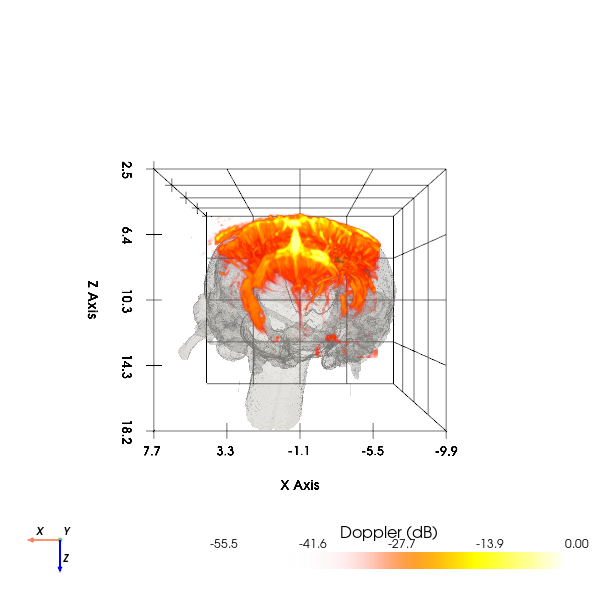

In [779]:
plotter2 = add_regions_mesh(pv_brain_probe,
                            notebook=True, window_size=[600, 600],
                            kwargs_dict={region_names[0]: {"color": "lightgray", "opacity": 0.2},	 
                                        region_names[1]: {"color": "permanentgreen", "opacity": 0.4}, 
                                        region_names[2]: {"color": "cadmiumlemon", "opacity": 0.6}})

plotter2 = add_doppler_vol(doppler3D_probe, plotter = plotter2, cmap="hot", opacity="sigmoid")
plotter2.show_grid(font_size = 10 )
plotter2.camera_position = 'xz'  # Set the camera position
plotter2.camera.up = (0, 0, -1)  # Set the camera up direction
plotter2.show(jupyter_backend='static',title="Doppler Volume")

# 4 Add transducer and 2D acquision

During the experiment we have 3 spaces: Brain, Lab, Probe. Once we manage to have our atlas in lab coordinates, we could simplify them to Lab and probe. The lab reference frame will move averything around the probe reference frame. Then its pov is static. We must then take our transducer, set . The probe space will have its origin center in the probe, and if we have done a good aproximation of the length and height, then its x,y coordinates should not move

In [780]:
# Create transducer with elevation focus
import pysonogen.transducers as Transducers
print(Transducers.available_transducers())

n_elements = 128
pitch_mm = 0.11
element_width_mm = 0.108
element_height_mm = 1.5
elevation_focus_mm = 8  # mm
tx_freq = 12.5  # MHz


domino = Transducers.LinearArrayTransducer(
    n_elements         = n_elements,
    element_width_mm   = element_width_mm,
    element_height_mm  = element_height_mm,
    elevation_focus_mm = elevation_focus_mm,
    kerf_mm            = pitch_mm - element_width_mm,
    no_sub_x           = 1,
    no_sub_y           = 10,
    frequency_Hz       = tx_freq*1e6,  # MHz),
)

print(domino)


['LinearArrayTransducer', 'MatrixArrayTransducer']
Transducer initialized in 0.0297 seconds.
LinearArrayTransducer(n_elements=128, el_w_mm=0.108, el_h_mm=1.5, kerf_mm=0.002000000000000002, elev_focus_mm=8.0, no_sub_x=1, no_sub_y=10, fc_Hz=12500000.0, Apod type=None, tx_N_active=128, F_over_D=None)


Focus: 1.150 mm, 0.000 mm, 8.200 mm


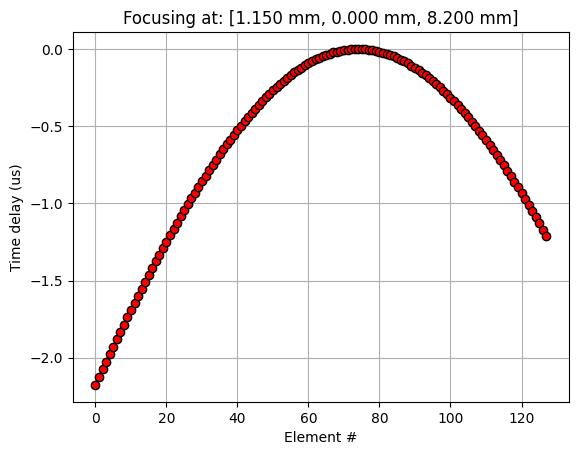

Focus: 1.150 mm, 0.000 mm, 8.200 mm


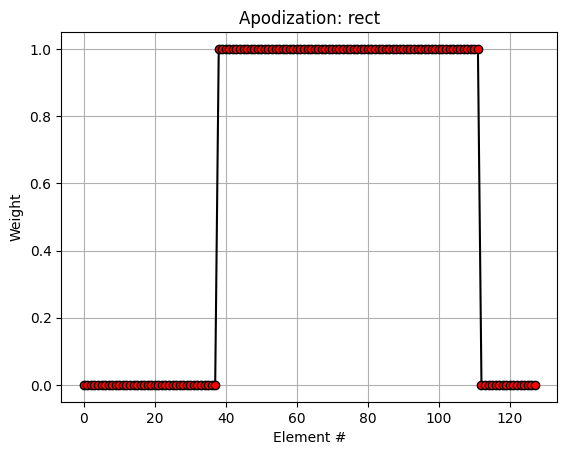

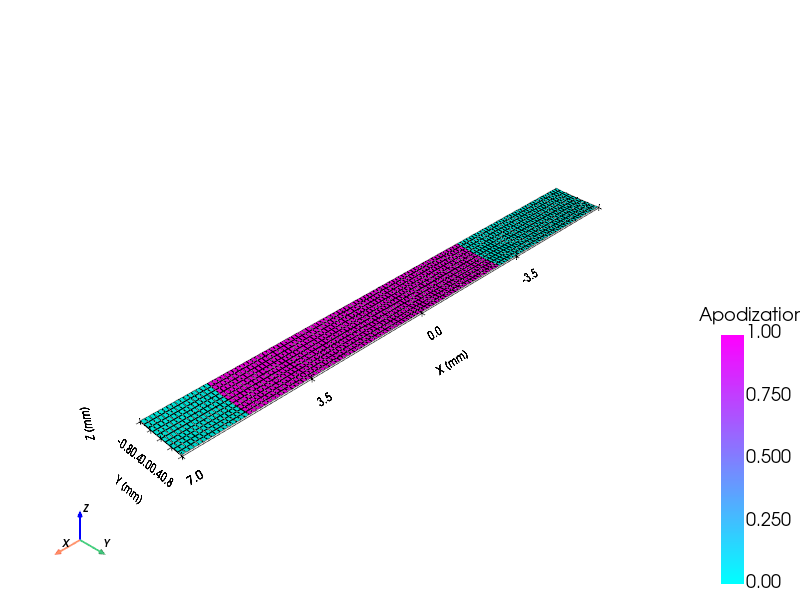

In [781]:
from pysonogen import pyfield

# Focalization spot
focus_mm =  np.array([1.15, 0, 8.2])  # mm [x, y, z]
delays = domino.compute_delays(focus_mm = focus_mm, plot = True)
apodization = domino.compute_apodization(focus_mm = focus_mm, F_over_D = 1, apodization_type='rect', plot = True)
domino.show(jupyter_backend='static')

In [782]:
TX_mesh = domino.get_mesh()

In [783]:
Bmode2D_dB = 20 * np.log10(np.abs(processed_scan_2D.squeeze()) / np.max(np.abs(processed_scan_2D.squeeze())))
Bmode2D_dB = np.clip(Bmode2D_dB, -60, 0)
doppler2D_probe = create_2D_image_mesh(Bmode2D_dB, rescale_m2mm  @  affine_matrix_2D['qform'])


In [784]:
plotter3 = add_regions_mesh(pv_brain_probe,
                            notebook=False, window_size=[800, 800],
                            kwargs_dict={region_names[0]: {"color": "lightgray", "opacity": 0.2},	 
                                        region_names[1]: {"color": "permanentgreen", "opacity": 0.4}, 
                                        region_names[2]: {"color": "cadmiumlemon", "opacity": 0.6}})

plotter3 = add_doppler_vol(doppler3D_probe, plotter = plotter3, cmap="hot", opacity="sigmoid")

plotter3 = add_transducer_mesh(TX_mesh,
                        plotter=plotter3, show_edges=False)

plotter3 = add_2D_image(doppler2D_probe, plotter=plotter3, cmap='gray', opacity=1.0, show_scalar_bar=True)

plotter3.show_axes()
plotter3.show_grid(
    font_size = 10, n_zlabels = 3, n_xlabels = 3
)

plotter3.camera_position = 'zx'  # Set the camera position
plotter3.camera.up = (0, 0, -1)

plotter3.add_legend(loc = 'upper left')             # show legend
plotter3.show() # ,

# 5. Add Pressure Field

In [785]:
Domino_field = pyfield.PyField(domino)
field_info_mm = {
    "x_extent" : [-0.25+focus_mm[0], 0.25+focus_mm[0]],
    "y_extent" : [-0.5+focus_mm[1], 0.5+focus_mm[1]],
    "z_extent" : [-1+focus_mm[2], 1+focus_mm[2]],
    "dx" : 0.0125,
    "dy" : 0.025,
    "dz" : 0.05,
}
print("Field info:", field_info_mm)
# pressure_field, x, y, z = Domino_field.compute_pressure_field(field_info_mm)

Successfully initialized PyField with 
 LinearArrayTransducer(n_elements=128, el_w_mm=0.108, el_h_mm=1.5, kerf_mm=0.002000000000000002, elev_focus_mm=8.0, no_sub_x=1, no_sub_y=10, fc_Hz=12500000.0, Apod type=rect, tx_N_active=74, F_over_D=1)
Field info: {'x_extent': [np.float64(0.8999999999999999), np.float64(1.4)], 'y_extent': [np.float64(-0.5), np.float64(0.5)], 'z_extent': [np.float64(7.199999999999999), np.float64(9.2)], 'dx': 0.0125, 'dy': 0.025, 'dz': 0.05}


Taking slice x_ind, y_ind, z_ind = 21/41, 21/41, 21/41


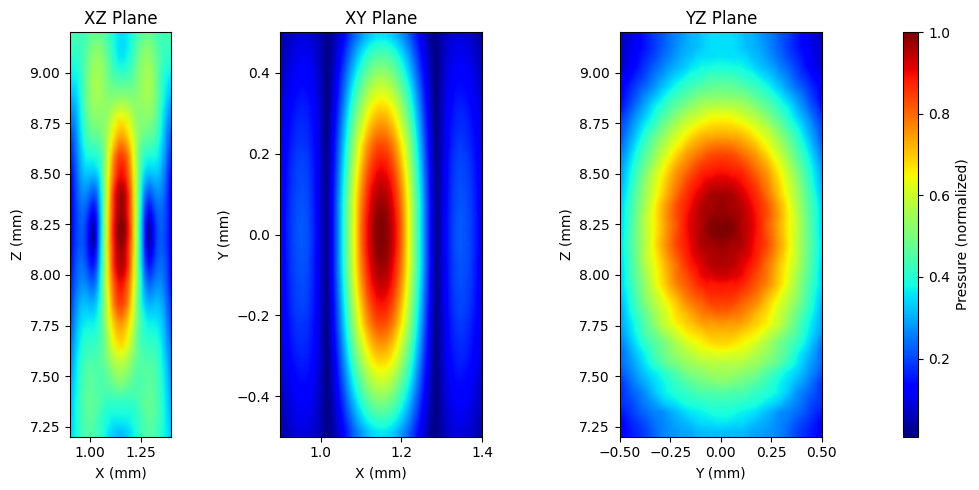

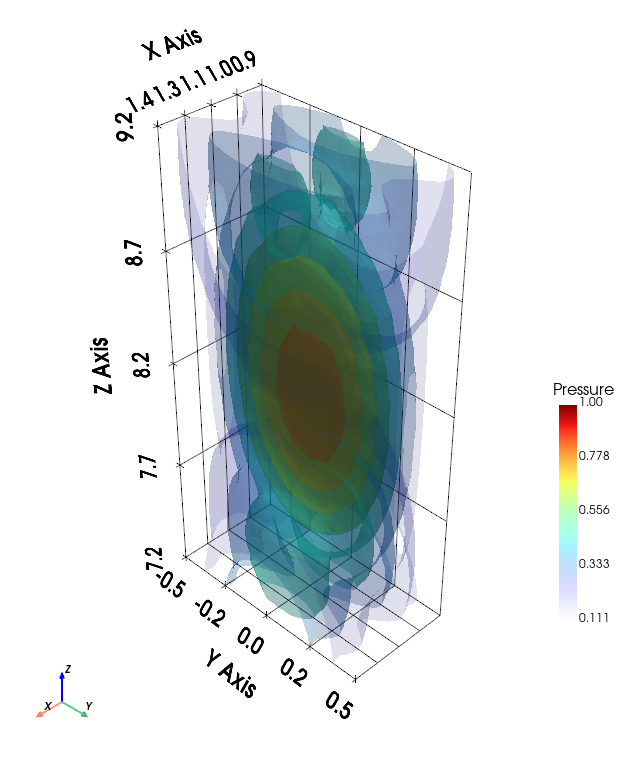

In [786]:
import pysonogen
pysonogen.plot_field_planes(pressure_field,
                               x, y, z, figsize = (10, 5), interpolation="bilinear")

pressure_plotter, pressure_vol_mesh = pysonogen.plot_pressure_field(pressure_field,
                               x, y, z, notebook = True, return_mesh = True, window_size = [620, 780])

pressure_plotter.show(jupyter_backend='static')  # Add this parameter

# 5. Plot brain and pressure field

In [787]:
final_plotter = add_regions_mesh(pv_brain_probe,
                            notebook=False, window_size=[800, 800],
                            kwargs_dict={region_names[0]: {"color": "lightgray", "opacity": 0.2},	 
                                        region_names[1]: {"color": "permanentgreen", "opacity": 0.2}, 
                                        region_names[2]: {"color": "cadmiumlemon", "opacity": 0.2}})

final_plotter = add_doppler_vol(doppler3D_probe, plotter = final_plotter,
                                cmap="hot", opacity="sigmoid", opacity_unit_distance = 15)

final_plotter = add_transducer_mesh(TX_mesh,
                        plotter=final_plotter, show_edges=False)

final_plotter = add_2D_image(doppler2D_probe, plotter=final_plotter, cmap='gray', opacity=1.0, show_scalar_bar=True)

final_plotter = add_pressure_vol(pressure_vol_mesh,
                        plotter=final_plotter,
                        plot_focal_spot=True)

final_plotter.camera.up = (0, 0, -1)
final_plotter.show_axes()
final_plotter.show_grid(
    font_size = 10, n_zlabels = 3, n_xlabels = 3
)
final_plotter.add_legend(loc = 'upper left')             # show legend
final_plotter.show() # ,

In [788]:
make_movie = False

if make_movie:

    video_plotter = add_regions_mesh(pv_brain_probe,
                                notebook=False, window_size=[800, 800],
                                kwargs_dict={region_names[0]: {"color": "lightgray", "opacity": 0.2},	 
                                            region_names[1]: {"color": "permanentgreen", "opacity": 0.4}, 
                                            region_names[2]: {"color": "cadmiumlemon", "opacity": 0.6}})

    video_plotter = add_doppler_vol(doppler3D_probe, plotter = video_plotter, cmap="hot", opacity="sigmoid")

    video_plotter = add_transducer_mesh(TX_mesh,
                            plotter=video_plotter, show_edges=False)

    video_plotter = add_2D_image(doppler2D_probe, plotter=video_plotter, cmap='gray', opacity=1.0, show_scalar_bar=True)

    video_plotter = add_pressure_vol(pressure_vol_mesh,
                            plotter=video_plotter,
                            plot_focal_spot=True)

    video_plotter.camera.up = (0, 0, -1)
    video_plotter.camera_position = 'zx'  # Set the camera position
    video_plotter.show_axes()
    video_plotter.show_grid(
        font_size = 10, n_zlabels = 3, n_xlabels = 3
    )
    video_plotter.add_legend(loc = 'upper left')             # show legend


    # Render once before movie to apply camera and settings
    video_plotter.render()

    # Open movie file and define frame settings
    n_frames = 180
    video_filename = "sonogen_experiment.mp4"
    video_plotter.open_movie(video_filename, framerate=20)

    # Rotation loop
    video_plotter.show(auto_close=False)

    delta_angle_deg = 360 / n_frames
    angle_deg = 0 
    for i in range(n_frames):
        angle_deg += 2
        video_plotter.camera.azimuth = angle_deg # Rotate camera
        video_plotter.render()
        video_plotter.write_frame()

    # Finalize and save
    video_plotter.close()
    print(f" Video saved to: {video_filename}")